# CP5 · Notebook 05 — Entrenar DQN

**Algoritmo**: DQN (Deep Q-Network) con `stable-baselines3`.

**Tiempo**: 5–10 min CPU para 20.000 timesteps.

**Objetivo**: superar al baseline rule-based (target del notebook 04).

In [1]:
import json, time, numpy as np
from pathlib import Path
import gymnasium as gym
import highway_env
from gymnasium.wrappers import FlattenObservation
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt

OUT = Path('../outputs'); OUT.mkdir(exist_ok=True)
MODELS = Path('../models'); MODELS.mkdir(exist_ok=True)

objc[26375]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x112a38bf8) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112f389c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[26375]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x112a38c48) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112f38a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[26375]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib 

## 1. Construir entorno de training

Usamos `FlattenObservation` porque DQN espera vectores 1D.

In [2]:
def make_train_env():
    env = gym.make('highway-v0', config={
        'observation': {'type': 'Kinematics', 'vehicles_count': 5,
                         'features': ['presence','x','y','vx','vy'], 'normalize': True},
        'action': {'type': 'DiscreteMetaAction'},
        'lanes_count': 4, 'vehicles_count': 20, 'duration': 40,
        'policy_frequency': 5,
    })
    return FlattenObservation(env)

env = make_train_env()
print(f'Observation flatten: {env.observation_space}')
print(f'Action: {env.action_space}')

Observation flatten: Box(-inf, inf, (25,), float32)
Action: Discrete(5)


## 2. Crear el agente DQN

Hiperparámetros — partir de defaults de SB3 con un par de ajustes para CPU.

In [3]:
model = DQN(
    'MlpPolicy', env,
    policy_kwargs=dict(net_arch=[256, 256]),   # red de la receta oficial de highway-env
    learning_rate=5e-4,
    buffer_size=15_000,
    learning_starts=200,
    batch_size=32,
    tau=1.0,
    gamma=0.8,                # highway-env: episodios cortos, recompensa densa -> gamma bajo
    train_freq=1,
    gradient_steps=1,
    target_update_interval=50,
    exploration_fraction=0.7,
    exploration_final_eps=0.05,
    verbose=0,
    seed=0,
)
print('DQN creado')
print(f'  device: {model.device}')
print(f'  policy net: {sum(p.numel() for p in model.policy.parameters())/1e3:.1f}k params')

DQN creado
  device: cpu
  policy net: 147.5k params


## 3. Callback para logging del return medio

In [4]:
class ReturnLogger(BaseCallback):
    def __init__(self, log_every=1000, verbose=0):
        super().__init__(verbose)
        self.log_every = log_every
        self.timesteps, self.returns_avg = [], []
        self.episode_returns = []
        self.current_episode_return = 0.0
    def _on_step(self):
        rewards = self.locals.get('rewards', [0])
        self.current_episode_return += rewards[0]
        if self.locals.get('dones', [False])[0]:
            self.episode_returns.append(self.current_episode_return)
            self.current_episode_return = 0.0
        if self.num_timesteps % self.log_every == 0:
            recent = self.episode_returns[-20:] if self.episode_returns else [0]
            self.timesteps.append(self.num_timesteps)
            self.returns_avg.append(float(np.mean(recent)))
        return True

logger = ReturnLogger(log_every=1000)

## 4. Entrenamiento

20.000 timesteps. **Tiempo esperado**: 5–8 min en CPU moderno. Si es lento → reduce a 10.000.

In [5]:
TOTAL_TIMESTEPS = 40_000
t0 = time.time()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logger, progress_bar=True)
elapsed = time.time() - t0
print(f'\n✅ Entrenamiento completado: {TOTAL_TIMESTEPS} timesteps en {elapsed:.0f}s  ({TOTAL_TIMESTEPS/elapsed:.0f} steps/s)')

model.save(MODELS / 'dqn_highway.zip')
print(f'   modelo guardado en {MODELS / "dqn_highway.zip"}')

Output()


✅ Entrenamiento completado: 40000 timesteps en 441s  (91 steps/s)
   modelo guardado en ../models/dqn_highway.zip


## 5. Curva de aprendizaje

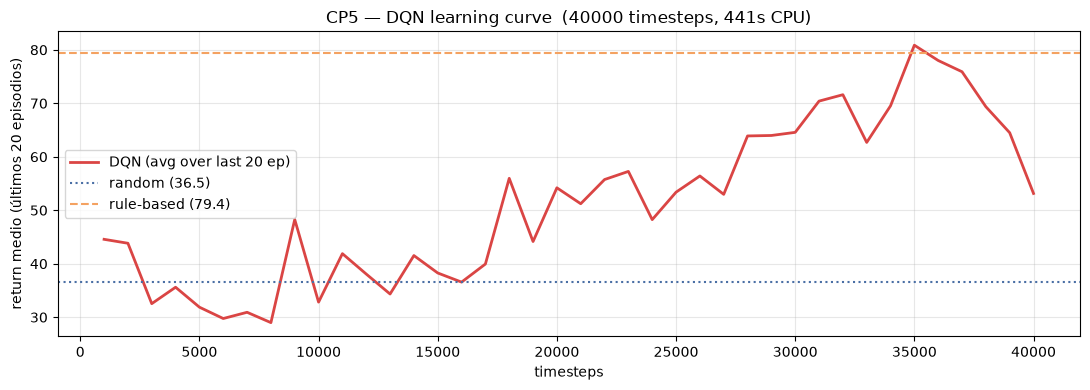


Return final (avg últimos 20 ep): 53.14
Ve a 06_evaluacion.ipynb para comparar formalmente con baselines.


In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(logger.timesteps, logger.returns_avg, '-', color='#DA4544', linewidth=2, label='DQN (avg over last 20 ep)')

# Cargar baselines del notebook 04 si existen
baselines_path = OUT / '04_baselines.json'
if baselines_path.exists():
    with open(baselines_path) as f:
        bl = json.load(f)
    ax.axhline(bl['random']['mean_return'], linestyle=':', color='#4a6fa5', label=f"random ({bl['random']['mean_return']:.1f})")
    ax.axhline(bl['rule_based']['mean_return'], linestyle='--', color='#f4a261', label=f"rule-based ({bl['rule_based']['mean_return']:.1f})")

ax.set_xlabel('timesteps')
ax.set_ylabel('return medio (últimos 20 episodios)')
ax.set_title(f'CP5 — DQN learning curve  ({TOTAL_TIMESTEPS} timesteps, {elapsed:.0f}s CPU)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / '05_learning_curve.png', dpi=100, bbox_inches='tight'); plt.show()

with open(OUT / '05_training_log.json', 'w') as f:
    json.dump({
        'total_timesteps': TOTAL_TIMESTEPS,
        'elapsed_seconds': elapsed,
        'timesteps_logged': logger.timesteps,
        'returns_avg': logger.returns_avg,
        'final_return_avg': logger.returns_avg[-1] if logger.returns_avg else None,
    }, f, indent=2)

print(f'\nReturn final (avg últimos 20 ep): {logger.returns_avg[-1] if logger.returns_avg else "N/A":.2f}')
print('Ve a 06_evaluacion.ipynb para comparar formalmente con baselines.')